# Notebook 01: Data Loading and Exploratory Data Analysis

## TVQA-Long Dataset

This notebook is the first step in building a multimodal RAG pipeline for video question answering. Before we can build any retrieval or generation components, we need to understand the data we are working with.

**Goals of this notebook:**
1. Load the TVQA validation annotations and flatten them into a workable DataFrame
2. Understand the distribution of questions across TV shows
3. Analyze question types (What/Why/How/Where/Who/When)
4. Examine answer option lengths to understand expected response verbosity
5. Analyze timestamp spans to understand how long video clips are
6. Load and explore the preprocessed subtitles
7. Extract and analyze speaker frequency from subtitles
8. Produce a summary statistics table

Understanding these distributions will inform downstream design decisions such as chunk sizes for retrieval, whether temporal context matters, and which shows dominate the evaluation set.

## Setup and Configuration

We begin by importing all necessary libraries and defining paths. We use `pathlib` for cross-platform path handling and define a single `PROJECT_ROOT` so that all data references are relative and reproducible.

In [1]:
import json
import re
from pathlib import Path
from collections import Counter

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration
PROJECT_ROOT = Path("/Users/nipun.batra/Downloads/ML/multimodal-rag-video-qa")
DATA_DIR = PROJECT_ROOT / "data" / "tvqa"
PLOTS_DIR = PROJECT_ROOT / "notebooks" / "tvqa" / "plots"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

# Plot style
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 12

print(f"Project root: {PROJECT_ROOT}")
print(f"Data directory: {DATA_DIR}")
print(f"Plots directory: {PLOTS_DIR}")

Project root: /Users/nipun.batra/Downloads/ML/multimodal-rag-video-qa
Data directory: /Users/nipun.batra/Downloads/ML/multimodal-rag-video-qa/data/tvqa
Plots directory: /Users/nipun.batra/Downloads/ML/multimodal-rag-video-qa/notebooks/tvqa/plots


## 1. Load Annotations and Flatten to DataFrame

The annotation file (`tvqa_val_edited.json`) stores questions in a deeply nested structure: show -> season -> episode -> questions list. This is convenient for hierarchical browsing but not for analysis. We flatten it into a single pandas DataFrame where each row is one question, carrying along the show, season, and episode metadata.

**Why flatten?** A flat DataFrame allows vectorized operations, groupby aggregations, and easy plotting -- all critical for efficient EDA.

In [2]:
# Load the nested annotation JSON
with open(DATA_DIR / "annotations" / "tvqa_val_edited.json") as f:
    annotations_raw = json.load(f)

# Flatten into a list of dicts
records = []
for show, seasons in annotations_raw.items():
    for season, episodes in seasons.items():
        for episode, ep_data in episodes.items():
            for q in ep_data["questions"]:
                record = q.copy()
                record["show"] = show
                record["season"] = season
                record["episode"] = episode
                records.append(record)

df = pd.DataFrame(records)
print(f"DataFrame shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")
print(f"\nFirst 3 rows:")
df.head(3)

DataFrame shape: (15253, 14)

Columns: ['a0', 'a1', 'a2', 'a3', 'a4', 'answer_idx', 'q', 'qid', 'show_name', 'ts', 'vid_name', 'show', 'season', 'episode']

First 3 rows:


,a0,a1,a2,a3,a4,answer_idx,q,qid,show_name,ts,vid_name,show,season,episode
0,Because Sheldon is being rude.,Because he doesn't like Sheldon.,Because they are having an argument.,Because Howard wanted to have a private meal w...,Because Sheldon won't loan him money for food.,2,Why is Howard frustrated when he is talking to...,122039,The Big Bang Theory,20.16-25.12,s03e02_seg02_clip_10,The Big Bang Theory,season_3,episode_2
1,singing,making out,eating dinner,cooking dinner,getting ready for bed,1,What were Penny and Leonard doing when they we...,122198,The Big Bang Theory,6.71-17.7,s03e02_seg02_clip_06,The Big Bang Theory,season_3,episode_2
2,Howard said Gryllus assimilis stood for love.,"Howard said Gryllus assimilis stood for ""suck,...",Howard said Gryllus assimilis stood for anger.,Howard said Gryllus assimilis stood for celebr...,Howard said Gryllus assimilis stood for danger.,1,What did Howard say Gryllus assimilis stood fo...,122351,The Big Bang Theory,3.41-5.89,s03e02_seg02_clip_10,The Big Bang Theory,season_3,episode_2


### Interpretation: Annotation Structure

The flattened DataFrame contains one row per question. Key columns include:
- **q**: The natural language question
- **a0 through a4**: Five multiple-choice answer options
- **answer_idx**: Index (0-4) of the correct answer
- **ts**: Timestamp range in seconds (e.g., "20.16-25.12") indicating which segment of the video is relevant
- **vid_name**: Identifies the specific video clip
- **show, season, episode**: Hierarchical metadata we added during flattening

Let us verify the total count and check for missing values.

In [3]:
print(f"Total questions: {len(df):,}")
print(f"Unique shows: {df['show'].nunique()}")
print(f"Unique episodes (vid_name): {df['vid_name'].nunique()}")
print(f"\nMissing values per column:")
print(df.isnull().sum())

Total questions: 15,253
Unique shows: 6
Unique episodes (vid_name): 2179

Missing values per column:
a0            0
a1            0
a2            0
a3            0
a4            0
answer_idx    0
q             0
qid           0
show_name     0
ts            0
vid_name      0
show          0
season        0
episode       0
dtype: int64


## 2. Distribution of Questions per Show

Understanding how questions are distributed across shows is important for two reasons:
1. It tells us whether certain shows dominate the evaluation set (potential bias)
2. It helps us decide whether show-specific strategies might be warranted

We plot a horizontal bar chart sorted by count so the most question-rich show is immediately visible.

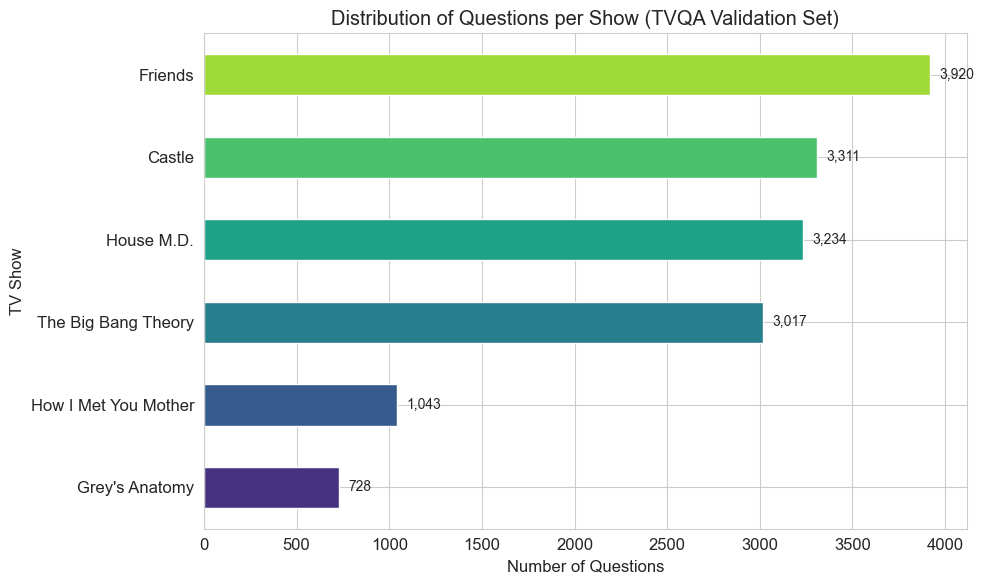


Questions per show:
  Grey's Anatomy: 728 (4.8%)
  How I Met You Mother: 1,043 (6.8%)
  The Big Bang Theory: 3,017 (19.8%)
  House M.D.: 3,234 (21.2%)
  Castle: 3,311 (21.7%)
  Friends: 3,920 (25.7%)


In [4]:
show_counts = df["show"].value_counts().sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
show_counts.plot(kind="barh", ax=ax, color=sns.color_palette("viridis", len(show_counts)))
ax.set_xlabel("Number of Questions")
ax.set_ylabel("TV Show")
ax.set_title("Distribution of Questions per Show (TVQA Validation Set)")

# Add count labels
for i, (val, name) in enumerate(zip(show_counts.values, show_counts.index)):
    ax.text(val + 50, i, f"{val:,}", va="center", fontsize=10)

plt.tight_layout()
plt.savefig(PLOTS_DIR / "01_questions_per_show.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nQuestions per show:")
for show, count in show_counts.items():
    print(f"  {show}: {count:,} ({count/len(df)*100:.1f}%)")

### Interpretation: Questions per Show

The distribution reveals how balanced (or imbalanced) the validation set is across TV shows. Shows with more questions will naturally have more influence on aggregate metrics. If one show dominates, performance on that show will disproportionately affect overall accuracy.

**Key takeaway:** When reporting results, we should consider both overall accuracy and per-show accuracy to ensure our RAG pipeline does not simply overfit to the most represented show.

## 3. Question Type Analysis

Different question types require different reasoning capabilities:
- **What** questions often ask about objects, actions, or events (visual + textual)
- **Why** questions require causal reasoning (often needs dialogue context)
- **How** questions may ask about manner or process
- **Where** questions need spatial understanding
- **Who** questions need character identification
- **When** questions need temporal reasoning

We extract the first word of each question to classify it and examine the distribution. This tells us which reasoning capabilities are most tested.

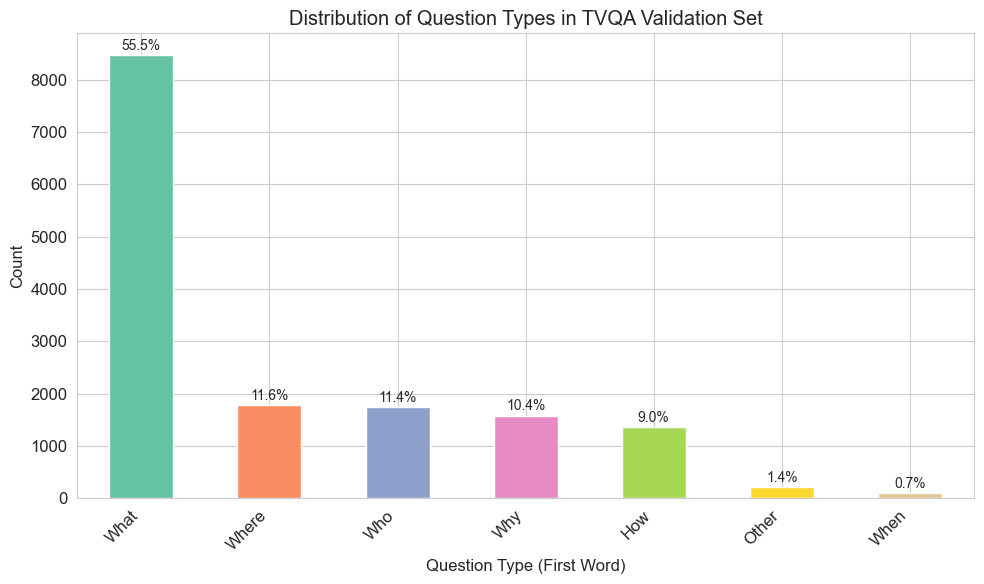


Question type distribution:
  What: 8,466 (55.5%)
  Where: 1,776 (11.6%)
  Who: 1,745 (11.4%)
  Why: 1,581 (10.4%)
  How: 1,368 (9.0%)
  Other: 217 (1.4%)
  When: 100 (0.7%)


In [5]:
# Extract the first word (question type)
df["q_type"] = df["q"].str.split().str[0].str.capitalize()

# Define the main question types we care about
main_types = ["What", "Why", "How", "Where", "Who", "When"]
df["q_type_grouped"] = df["q_type"].apply(lambda x: x if x in main_types else "Other")

type_counts = df["q_type_grouped"].value_counts()

fig, ax = plt.subplots(figsize=(10, 6))
colors = sns.color_palette("Set2", len(type_counts))
type_counts.plot(kind="bar", ax=ax, color=colors)
ax.set_xlabel("Question Type (First Word)")
ax.set_ylabel("Count")
ax.set_title("Distribution of Question Types in TVQA Validation Set")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")

# Add percentage labels
for i, (val, label) in enumerate(zip(type_counts.values, type_counts.index)):
    ax.text(i, val + 100, f"{val/len(df)*100:.1f}%", ha="center", fontsize=10)

plt.tight_layout()
plt.savefig(PLOTS_DIR / "01_question_types.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nQuestion type distribution:")
for qtype, count in type_counts.items():
    print(f"  {qtype}: {count:,} ({count/len(df)*100:.1f}%)")

### Interpretation: Question Types

The question type distribution tells us which cognitive capabilities our pipeline needs most. If "What" dominates, we need strong entity/event recognition. If "Why" is prevalent, we need causal reasoning from dialogue and visual cues.

**Implication for RAG design:** The dominant question types should guide what information we prioritize in our retrieval step -- e.g., if causal (Why) questions are common, retrieving surrounding dialogue context becomes critical.

## 4. Answer Option Length Analysis

Understanding how long answer options are (in words) helps us calibrate expectations for generation length. Short answers (2-5 words) suggest factoid-style responses, while longer answers (10+ words) suggest more complex, descriptive responses.

We compute the word count for all five answer options (a0 through a4) and examine the distribution.

In [6]:
# Compute word counts for each answer option
answer_cols = ["a0", "a1", "a2", "a3", "a4"]
answer_lengths = []
for col in answer_cols:
    lengths = df[col].str.split().str.len()
    answer_lengths.append(lengths)

all_answer_lengths = pd.concat(answer_lengths, ignore_index=True)

print(f"Answer option length statistics (in words):")
print(f"  Mean:   {all_answer_lengths.mean():.1f}")
print(f"  Median: {all_answer_lengths.median():.1f}")
print(f"  Std:    {all_answer_lengths.std():.1f}")
print(f"  Min:    {all_answer_lengths.min()}")
print(f"  Max:    {all_answer_lengths.max()}")
print(f"  25th percentile: {all_answer_lengths.quantile(0.25):.1f}")
print(f"  75th percentile: {all_answer_lengths.quantile(0.75):.1f}")

Answer option length statistics (in words):
  Mean:   4.6
  Median: 4.0
  Std:    3.3
  Min:    1
  Max:    32
  25th percentile: 2.0
  75th percentile: 6.0


### Interpretation: Answer Lengths

The statistics above show us the expected verbosity of correct answers. This is relevant because:
- If answers are short, our model needs to be precise and concise
- If answers are long, retrieval needs to supply enough context for the model to synthesize a detailed response

**For multiple-choice QA**, the model must discriminate between options rather than generate free-form text, so understanding option lengths helps us gauge the complexity of each discrimination task.

## 5. Timestamp Span Analysis

Each question references a video clip via a timestamp range (e.g., "20.16-25.12" means seconds 20.16 to 25.12). The span duration tells us how much video context is relevant to each question.

**Why this matters:**
- Short spans (under 5 seconds) might be answerable from a single frame or sentence
- Long spans (over 30 seconds) require understanding extended dialogue or action sequences
- This informs our chunking strategy for the RAG retrieval component

Clip duration statistics (seconds):
  Mean:   11.23
  Median: 8.12
  Std:    11.19
  Min:    0.00
  Max:    121.31
  Missing: 6


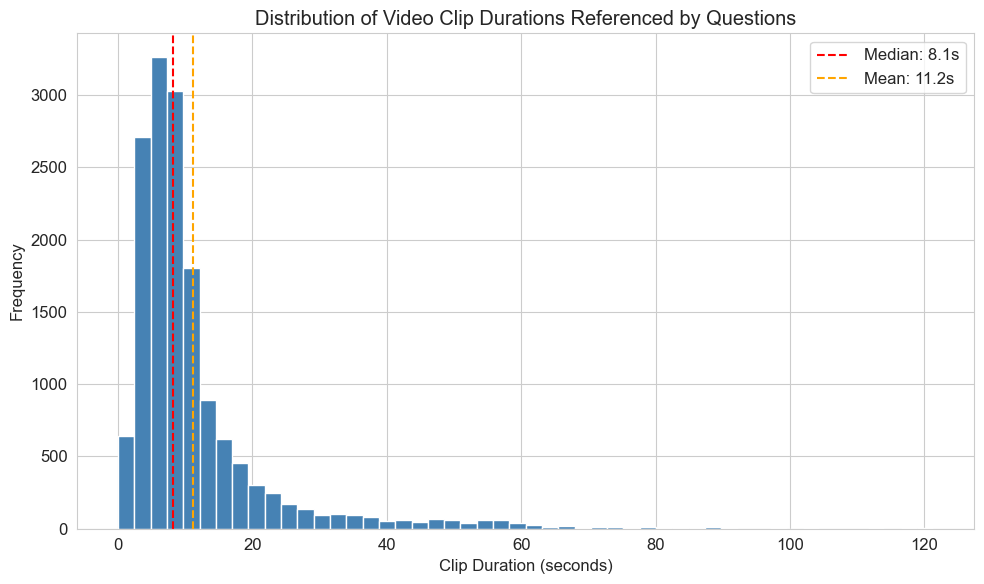

In [7]:
# Parse timestamp spans
def parse_timestamp(ts_str):
    """Parse 'start-end' timestamp string and return duration in seconds."""
    try:
        parts = ts_str.split("-")
        start = float(parts[0])
        end = float(parts[1])
        return end - start
    except (ValueError, IndexError):
        return np.nan

df["clip_duration"] = df["ts"].apply(parse_timestamp)

print(f"Clip duration statistics (seconds):")
print(f"  Mean:   {df['clip_duration'].mean():.2f}")
print(f"  Median: {df['clip_duration'].median():.2f}")
print(f"  Std:    {df['clip_duration'].std():.2f}")
print(f"  Min:    {df['clip_duration'].min():.2f}")
print(f"  Max:    {df['clip_duration'].max():.2f}")
print(f"  Missing: {df['clip_duration'].isna().sum()}")

fig, ax = plt.subplots(figsize=(10, 6))
df["clip_duration"].dropna().hist(bins=50, ax=ax, color="steelblue", edgecolor="white")
ax.axvline(df["clip_duration"].median(), color="red", linestyle="--", label=f"Median: {df['clip_duration'].median():.1f}s")
ax.axvline(df["clip_duration"].mean(), color="orange", linestyle="--", label=f"Mean: {df['clip_duration'].mean():.1f}s")
ax.set_xlabel("Clip Duration (seconds)")
ax.set_ylabel("Frequency")
ax.set_title("Distribution of Video Clip Durations Referenced by Questions")
ax.legend()
plt.tight_layout()
plt.savefig(PLOTS_DIR / "01_timestamp_spans.png", dpi=150, bbox_inches="tight")
plt.show()

### Interpretation: Timestamp Spans

The clip duration distribution shows us the temporal granularity of questions in TVQA. Most clips are relatively short, which suggests that questions tend to focus on specific moments rather than requiring understanding of entire scenes.

**Design implication:** Our retrieval system should be able to identify and return content from short temporal windows (typically a few seconds). Chunks that are too coarse (e.g., entire episode transcripts) would include too much irrelevant context.

## 6. Load Preprocessed Subtitles

The preprocessed subtitles file contains dialogue for individual video clips (not full episodes). Each entry maps a `vid_name` to a list of subtitle segments with start/end times and text.

**Why explore subtitles?** In a multimodal RAG pipeline for video QA, subtitles (dialogue) are often the richest textual signal. Understanding subtitle coverage, density, and length will help us design effective text chunking and retrieval.

In [8]:
# Load preprocessed subtitles
with open(DATA_DIR / "annotations" / "tvqa_preprocessed_subtitles.json") as f:
    subtitles_raw = json.load(f)

print(f"Total subtitle entries (clips): {len(subtitles_raw):,}")
print(f"\nSample entry keys: {list(subtitles_raw[0].keys())}")
print(f"Sample vid_name: {subtitles_raw[0]['vid_name']}")
print(f"Sample subtitle count: {len(subtitles_raw[0]['sub'])} segments")
print(f"\nFirst 3 subtitle segments:")
for seg in subtitles_raw[0]["sub"][:3]:
    print(f"  [{seg['start']:.2f}s - {seg['end']:.2f}s] {seg['text'].strip()}")

Total subtitle entries (clips): 21,793

Sample entry keys: ['vid_name', 'sub']
Sample vid_name: house_s02e05_seg02_clip_11
Sample subtitle count: 40 segments

First 3 subtitle segments:
  [0.86s - 1.86s] Chase : That's all this is?
  [1.99s - 2.86s] Yeah.
  [2.99s - 5.28s] House : Because his white blood cell count was down, he was vulnerable.


### Subtitle Coverage by Show

We extract the show name from the `vid_name` field to see how subtitle clips are distributed across shows. The `vid_name` follows patterns like `house_s02e05_seg02_clip_11` or `grey_s02e09_seg02_clip_06` where the prefix identifies the show.

In [9]:
# Build a DataFrame of subtitle metadata
sub_records = []
for entry in subtitles_raw:
    vid_name = entry["vid_name"]
    subs = entry["sub"]
    total_text = " ".join(seg["text"].strip() for seg in subs)
    sub_records.append({
        "vid_name": vid_name,
        "num_segments": len(subs),
        "total_words": len(total_text.split()),
        "total_chars": len(total_text),
    })

df_subs = pd.DataFrame(sub_records)

# Extract show prefix from vid_name
# Patterns: house_s, grey_s, castle_s, met_s, bbt_s, friends_s
def extract_show_from_vid(vid_name):
    prefix = vid_name.split("_s")[0]
    show_map = {
        "house": "House M.D.",
        "grey": "Grey's Anatomy",
        "castle": "Castle",
        "met": "How I Met Your Mother",
        "bbt": "The Big Bang Theory",
        "friends": "Friends",
    }
    return show_map.get(prefix, prefix)

df_subs["show"] = df_subs["vid_name"].apply(extract_show_from_vid)

print("Subtitle clips per show:")
clips_per_show = df_subs["show"].value_counts()
for show, count in clips_per_show.items():
    print(f"  {show}: {count:,}")

print(f"\nAverage subtitle segments per clip: {df_subs['num_segments'].mean():.1f}")
print(f"Average words per clip: {df_subs['total_words'].mean():.1f}")
print(f"Median words per clip: {df_subs['total_words'].median():.1f}")

Subtitle clips per show:
  Friends: 5,337
  Castle: 4,698
  House M.D.: 4,621
  How I Met Your Mother: 1,512
  Grey's Anatomy: 1,427
  s01e01: 22
  s01e03: 21
  s01e15: 21
  s04e03: 21
  s02e14: 21
  s10e01: 21
  s02e01: 21
  s02e13: 21
  s04e12: 21
  s05e20: 21
  s02e21: 21
  s04e19: 21
  s03e02: 20
  s04e01: 20
  s07e01: 20
  s02e15: 20
  s03e18: 20
  s01e11: 20
  s04e22: 20
  s04e13: 20
  s04e20: 20
  s02e02: 20
  s06e08: 20
  s02e11: 20
  s06e24: 20
  s05e06: 20
  s02e12: 20
  s01e04: 20
  s05e22: 20
  s02e10: 20
  s06e12: 20
  s02e09: 20
  s03e01: 20
  s04e14: 20
  s03e21: 20
  s04e06: 20
  s08e19: 20
  s05e23: 20
  s06e10: 20
  s09e11: 20
  s02e23: 20
  s02e03: 20
  s02e06: 20
  s01e13: 20
  s05e09: 20
  s02e07: 20
  s06e16: 20
  s05e01: 20
  s05e18: 20
  s08e01: 20
  s04e24: 20
  s01e06: 20
  s05e13: 20
  s05e05: 20
  s05e16: 20
  s03e15: 20
  s07e04: 20
  s04e07: 20
  s02e04: 20
  s07e11: 20
  s06e02: 20
  s06e22: 20
  s07e13: 20
  s06e01: 20
  s07e22: 20
  s04e16: 20
  s09e10:

### Subtitle Length Distribution

We now visualize how long the subtitle text is per clip (in words). This tells us the information density available to our retrieval system for each video segment.

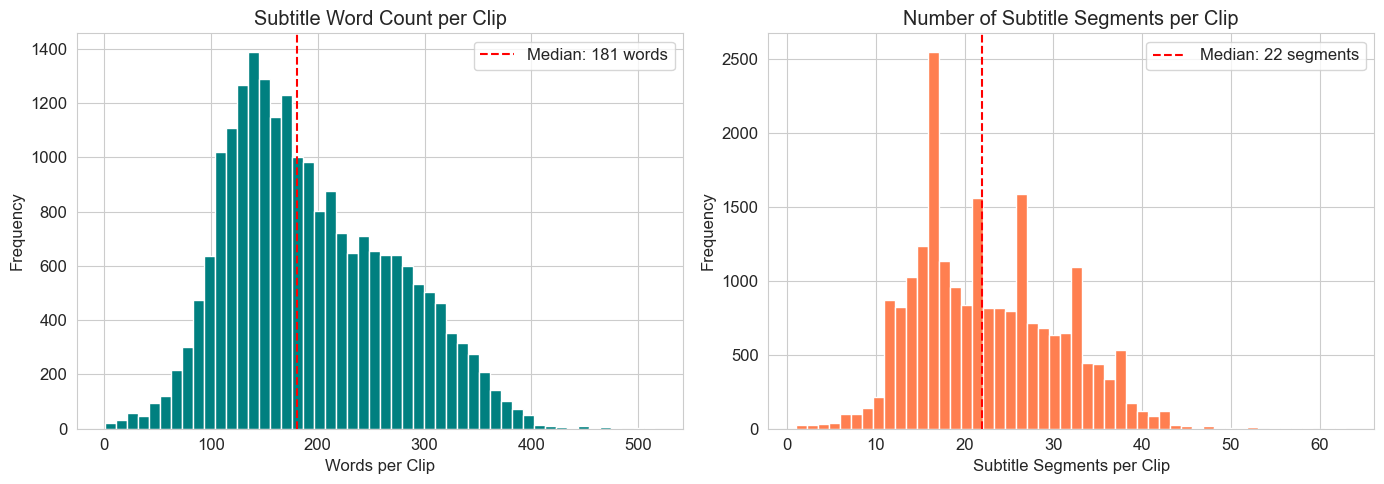

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: word count distribution
df_subs["total_words"].hist(bins=50, ax=axes[0], color="teal", edgecolor="white")
axes[0].axvline(df_subs["total_words"].median(), color="red", linestyle="--", 
                label=f"Median: {df_subs['total_words'].median():.0f} words")
axes[0].set_xlabel("Words per Clip")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Subtitle Word Count per Clip")
axes[0].legend()

# Right: segment count distribution
df_subs["num_segments"].hist(bins=50, ax=axes[1], color="coral", edgecolor="white")
axes[1].axvline(df_subs["num_segments"].median(), color="red", linestyle="--",
                label=f"Median: {df_subs['num_segments'].median():.0f} segments")
axes[1].set_xlabel("Subtitle Segments per Clip")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Number of Subtitle Segments per Clip")
axes[1].legend()

plt.tight_layout()
plt.savefig(PLOTS_DIR / "01_subtitle_lengths.png", dpi=150, bbox_inches="tight")
plt.show()

### Interpretation: Subtitle Lengths

The subtitle length distribution tells us how much textual information is available per video clip. Clips with very few words may rely more heavily on visual cues, while dialogue-rich clips provide ample text for retrieval.

**Key insight for chunking:** The median word count per clip gives us a natural unit for text chunks in our RAG pipeline. If most clips have a moderate number of words, each clip's subtitle can serve as a single retrieval unit without further splitting.

## 7. Subtitle Speaker Extraction

The subtitle text includes speaker labels in the format `" Speaker : dialogue text"`. Extracting speakers tells us:
1. Which characters appear most frequently (potential for character-aware retrieval)
2. How many distinct speakers exist (complexity of the dialogue landscape)
3. Whether speaker information could be a useful retrieval signal

We use a regex pattern to extract speaker names from subtitle text.

In [11]:
# Extract speakers from all subtitle text
speaker_counter = Counter()

for entry in subtitles_raw:
    for seg in entry["sub"]:
        # Pattern: text starts with " Speaker : " or "Speaker :"
        match = re.match(r"\s*([A-Za-z][A-Za-z\s\.'-]+?)\s*:", seg["text"])
        if match:
            speaker = match.group(1).strip()
            speaker_counter[speaker] += 1

print(f"Total unique speakers found: {len(speaker_counter):,}")
print(f"Total speaker-attributed lines: {sum(speaker_counter.values()):,}")
print(f"\nTop 20 most frequent speakers:")
print("-" * 40)
for speaker, count in speaker_counter.most_common(20):
    print(f"  {speaker:20s} {count:,} lines")

Total unique speakers found: 5,923
Total speaker-attributed lines: 357,881

Top 20 most frequent speakers:
----------------------------------------
  House                29,949 lines
  Beckett              26,463 lines
  Castle               25,897 lines
  Sheldon              19,223 lines
  Leonard              10,434 lines
  Esposito             8,172 lines
  Penny                7,991 lines
  Ryan                 7,960 lines
  Foreman              7,927 lines
  Howard               6,989 lines
  Wilson               6,270 lines
  Ross                 6,151 lines
  Rachel               6,040 lines
  Chase                5,958 lines
  Raj                  5,852 lines
  Monica               5,380 lines
  Chandler             5,353 lines
  Joey                 5,259 lines
  Ted                  5,165 lines
  Phoebe               5,090 lines


### Interpretation: Speaker Analysis

The speaker frequency list reveals the most talkative characters across the dataset. Main characters from each show naturally dominate. This information is valuable because:

- **Character-aware retrieval:** Questions often reference characters by name. Knowing which characters speak most helps us understand which dialogue is most likely to be relevant.
- **Speaker diversity:** A high number of unique speakers means our system must handle many character identities, making character resolution an important sub-task.

**Design implication:** Including speaker labels in our retrieval chunks can help the model associate dialogue with specific characters, improving QA accuracy for "Who said..." type questions.

## 8. Summary Statistics Table

We consolidate the key statistics discovered in this notebook into a single reference table. This serves as a quick reference for downstream notebook development and system design decisions.

In [12]:
# Build summary statistics
summary_data = {
    "Metric": [
        "Total validation questions",
        "Number of TV shows",
        "Unique video clips (annotations)",
        "Total subtitle entries",
        "Unique speakers in subtitles",
        "Mean clip duration (seconds)",
        "Median clip duration (seconds)",
        "Mean answer length (words)",
        "Mean subtitle words per clip",
        "Median subtitle words per clip",
        "Mean subtitle segments per clip",
    ],
    "Value": [
        f"{len(df):,}",
        f"{df['show'].nunique()}",
        f"{df['vid_name'].nunique():,}",
        f"{len(subtitles_raw):,}",
        f"{len(speaker_counter):,}",
        f"{df['clip_duration'].mean():.2f}",
        f"{df['clip_duration'].median():.2f}",
        f"{all_answer_lengths.mean():.1f}",
        f"{df_subs['total_words'].mean():.1f}",
        f"{df_subs['total_words'].median():.1f}",
        f"{df_subs['num_segments'].mean():.1f}",
    ],
}

df_summary = pd.DataFrame(summary_data)
print("=" * 55)
print("  TVQA-Long Dataset Summary Statistics")
print("=" * 55)
print(df_summary.to_string(index=False))
print("=" * 55)

  TVQA-Long Dataset Summary Statistics
                          Metric  Value
      Total validation questions 15,253
              Number of TV shows      6
Unique video clips (annotations)  2,179
          Total subtitle entries 21,793
    Unique speakers in subtitles  5,923
    Mean clip duration (seconds)  11.23
  Median clip duration (seconds)   8.12
      Mean answer length (words)    4.6
    Mean subtitle words per clip  194.5
  Median subtitle words per clip  181.0
 Mean subtitle segments per clip   22.6


### Final Summary and Next Steps

**Key findings from this exploratory analysis:**

1. The TVQA validation set contains thousands of questions distributed across 6 TV shows, providing a rich evaluation benchmark for multimodal QA.

2. Question types are diverse, with a mix of factual (What), causal (Why), and other reasoning types. This means our RAG pipeline needs multiple reasoning capabilities.

3. Video clips are typically short (a few seconds), meaning our retrieval system should operate at fine temporal granularity rather than episode-level.

4. Subtitles provide substantial textual signal, with each clip containing enough dialogue to serve as a natural retrieval chunk.

5. Speaker information is available and could serve as a useful metadata signal for character-aware retrieval.

**Next notebook (02):** We will preprocess the subtitles into a structured format suitable for embedding and retrieval, including chunking, speaker normalization, and temporal alignment with video frames.